In [1]:
import os, glob, warnings, gc, random
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed_everything(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
import os
SYNTHETIC_DATA = False
DAPT_BASE = r"C:\Users\ADMIN\Desktop\Dữ Liệu\dapt_2020\csv"
DAPT_CSV_PATHS = {
    1: [f'{DAPT_BASE}/enp0s3-monday.pcap_Flow.csv', f'{DAPT_BASE}/enp0s3-monday-pvt.pcap_Flow.csv'],
    2: [f'{DAPT_BASE}/enp0s3-public-tuesday.pcap_Flow.csv', f'{DAPT_BASE}/enp0s3-pvt-tuesday.pcap_Flow.csv'],
    3: [f'{DAPT_BASE}/enp0s3-public-wednesday.pcap_Flow.csv', f'{DAPT_BASE}/enp0s3-pvt-wednesday.pcap_Flow.csv'],
    4: [f'{DAPT_BASE}/enp0s3-public-thursday.pcap_Flow.csv', f'{DAPT_BASE}/enp0s3-pvt-thursday.pcap_Flow.csv'],
    5: [f'{DAPT_BASE}/enp0s3-tcpdump-friday.pcap_Flow.csv', f'{DAPT_BASE}/enp0s3-tcpdump-pvt-friday.pcap_Flow.csv'],
}
DAPT_LABEL_COL = 'Label'
# ============================================================
# MAPPING NHÃN → APT PHASE (0..4)
# ============================================================
ATTACK_TO_PHASE = {
    # Phase 0 — Benign
    'Benign': 0, 'benign': 0, 'BENIGN': 0, 'Normal': 0, 'normal': 0,

    # Phase 1 — Reconnaissance
    'Network Scan': 1, 'NetworkScan': 1, 'network scan': 1,
    'Web vulnerability Scan': 1, 'Web Vulnerability Scan': 1,
    'WebVulnerabilityScan': 1, 'Port Scan': 1, 'PortScan': 1,
    'Reconnaissance': 1,

    # Phase 2 — Foothold
    'SQL injection': 2, 'SQL Injection': 2, 'SQLInjection': 2,
    'Backdoor': 2, 'backdoor': 2,
    'Malware Download': 2, 'MalwareDownload': 2,
    'Command Injection': 2, 'CommandInjection': 2,
    'CSRF': 2, 'csrf': 2,
    'Account brute force': 2, 'AccountBruteForce': 2, 'BruteForce': 2,
    'Foothold': 2,
    'Establish Foothold': 2,  # <-- THÊM ĐỂ FIX LỖI 8604 DÒNG BỊ LỌT

    # Phase 3 — Lateral Movement
    'DoS': 3, 'dos': 3, 'DenialOfService': 3,
    'Privilege escalation': 3, 'PrivilegeEscalation': 3,
    'Lateral Movement': 3, 'LateralMovement': 3,

    # Phase 4 — Exfiltration
    'Data Exfiltration': 4, 'DataExfiltration': 4,
    'Exfiltration': 4, 'exfiltration': 4,
}
APT_PHASE_NAMES = [
    'Benign', 'Reconnaissance', 'Foothold', 'Lateral Movement', 'Exfiltration'
]

N_APT_PHASES = len(APT_PHASE_NAMES)

N_PCA       = 20
N_BINS      = 32
BATCH_SIZE  = 1024
NUM_WORKERS = 0
EPOCHS      = 5
LR          = 1e-3
D_MODEL     = 256
N_HEADS     = 8
N_PERSIST   = 4
SWA_WINDOW  = 16
LMM_LAYERS  = 2         
LMM_DROPOUT = 0.1        
HEAD_DROPOUT = 0.1      
OUTLIER_TH  = 3.0
PRE_BATCH   = 50_000

N_SYNTHETIC = 5000
N_FEATURES  = 40

print(f'Mode : {"SYNTHETIC" if SYNTHETIC_DATA else "REAL DAPT 2020 (sowmyamyneni/dapt2020)"}')
print(f'Phases: {N_APT_PHASES} | D_MODEL={D_MODEL} | Epochs={EPOCHS}')
if not SYNTHETIC_DATA:
    for day, paths in DAPT_CSV_PATHS.items():
        for path in paths:
            status = 'Ok' if os.path.exists(path) else 'Not ok'
            print(f'  Day {day}: {os.path.basename(path)} {status}')

Mode : REAL DAPT 2020 (sowmyamyneni/dapt2020)
Phases: 5 | D_MODEL=256 | Epochs=5
  Day 1: enp0s3-monday.pcap_Flow.csv Ok
  Day 1: enp0s3-monday-pvt.pcap_Flow.csv Ok
  Day 2: enp0s3-public-tuesday.pcap_Flow.csv Ok
  Day 2: enp0s3-pvt-tuesday.pcap_Flow.csv Ok
  Day 3: enp0s3-public-wednesday.pcap_Flow.csv Ok
  Day 3: enp0s3-pvt-wednesday.pcap_Flow.csv Ok
  Day 4: enp0s3-public-thursday.pcap_Flow.csv Ok
  Day 4: enp0s3-pvt-thursday.pcap_Flow.csv Ok
  Day 5: enp0s3-tcpdump-friday.pcap_Flow.csv Ok
  Day 5: enp0s3-tcpdump-pvt-friday.pcap_Flow.csv Ok


In [3]:
import os
def generate_synthetic_dapt(n_per_phase=1000, n_features=40, seed=42):
    np.random.seed(seed)
    dfs = []
    configs = [
        (0.3, 0.1, []),
        (0.5, 0.3, [0, 1, 2]),
        (0.6, 0.4, [5, 6, 7]),
        (0.7, 0.3, [10, 11]),
        (0.9, 0.5, [15, 16]),
    ]
    for phase_id, (mu, sigma, skew) in enumerate(configs):
        data = np.abs(np.random.randn(n_per_phase, n_features) * sigma + mu)
        for f in skew:
            data[:, f] += np.random.exponential(2.0, n_per_phase)
        df_p = pd.DataFrame(data, columns=[f'f{i}' for i in range(n_features)])
        df_p['APT_Phase'] = phase_id
        dfs.append(df_p)
    return pd.concat(dfs, ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)


def load_real_dapt(csv_paths, attack_to_phase, label_col_hint='Stage'):
    """Load DAPT 2020 từ Kaggle (sowmyamyneni/dapt2020) có xử lý header tự động."""
    # Bước 1: Thu thập tất cả các file tồn tại
    all_files = []
    for day, paths in csv_paths.items():
        if not isinstance(paths, list):
            paths = [paths]
        for path in paths:
            if os.path.exists(path):
                all_files.append((day, path))
            else:
                print(f'  [Day {day}] ⚠️ Không tìm thấy, bỏ qua: {path}')

    if not all_files:
        raise FileNotFoundError(f'Không tìm thấy bất kỳ file CSV nào tại: {DAPT_BASE}')

    # Bước 2: Tìm file có header để lấy bộ cột chuẩn
    standard_cols = None
    for day, path in all_files:
        with open(path, 'r', errors='ignore') as f:
            first_line = f.readline()
        # Check xem dòng đầu có chứa các từ khóa tiêu biểu của header không
        has_header = any(h in first_line.lower() for h in ["flow id", "flow_id", "src ip", "src_ip", "protocol", "timestamp"])
        if has_header:
            df_temp = pd.read_csv(path, nrows=5)
            standard_cols = list(df_temp.columns)
            print(f'  -> Lấy bộ cột chuẩn từ file có header: {os.path.basename(path)} ({len(standard_cols)} cột)')
            break

    if standard_cols is None:
        raise ValueError("Không tìm thấy file nào có header để lấy danh sách cột chuẩn!")

    # Bước 3: Load tất cả các file (cả có header và không header)
    dfs = []
    for day, path in all_files:
        with open(path, 'r', errors='ignore') as f:
            first_line = f.readline()
        has_header = any(h in first_line.lower() for h in ["flow id", "flow_id", "src ip", "src_ip", "protocol", "timestamp"])

        print(f'Loading Day {day}: {os.path.basename(path)} (Has Header: {has_header}) ...')
        try:
            if has_header:
                df_d = pd.read_csv(path, low_memory=False)
                # Đảm bảo giữ đúng số lượng và thứ tự cột chuẩn
                df_d = df_d.reindex(columns=standard_cols)
            else:
                # File không có header -> dùng standard_cols
                df_d = pd.read_csv(path, header=None, names=standard_cols, low_memory=False)
            
            df_d['Day'] = day
            dfs.append(df_d)
        except Exception as e:
            print(f'  ❌ Lỗi khi đọc file {os.path.basename(path)}: {e}')

    if not dfs:
        raise ValueError("Không load được dataframe nào.")

    df = pd.concat(dfs, ignore_index=True)
    print(f'Concat shape before dedup: {df.shape}')
    df = df.drop_duplicates()
    df = df.reset_index(drop=True)
    print(f'Concat shape after  dedup: {df.shape}')

    # Bước 4: Xác định cột nhãn (Stage hoặc Activity)
    label_col = None
    search_cols = []
    if label_col_hint:
        search_cols.append(label_col_hint)
    search_cols.extend(['Stage', 'stage', 'Activity', 'activity', 'Label', 'label', 'Attack', 'attack', 'Class', 'Category'])
    
    for c in search_cols:
        if c in df.columns:
            label_col = c
            break

    if label_col is None:
        raise ValueError(f'Không tìm thấy cột nhãn. Cột hiện có: {list(df.columns)}')
    print(f'Cột nhãn được chọn: "{label_col}"')

    # Hiển thị nhãn thực tế
    print('\nNhãn thực tế trong cột nhãn:')
    for lbl in sorted(df[label_col].dropna().unique()):
        print(f'  "{lbl}": {(df[label_col]==lbl).sum():,}')

    # Map nhãn → Phase
    # Map nhãn → Phase
    df['APT_Phase'] = df[label_col].map(attack_to_phase)
    unmapped_mask = df['APT_Phase'].isna()
    if unmapped_mask.any():
        unmapped_labels = df.loc[unmapped_mask, label_col].unique()
        raise ValueError(f'CRITICAL ERROR: Dữ liệu chứa các nhãn chưa được mapping: {unmapped_labels}')
    df['APT_Phase'] = df['APT_Phase'].astype(int)

    print('\nPhase Distribution:')
    for i, name in enumerate(APT_PHASE_NAMES):
        cnt = (df['APT_Phase']==i).sum()
        print(f'  Phase {i} ({name:<22}): {cnt:>10,} ({cnt/len(df)*100:5.1f}%)')
    
    return df, label_col


# -------- LOAD --------
if SYNTHETIC_DATA:
    print('🔬 Synthetic Mode')
    df = generate_synthetic_dapt(N_SYNTHETIC // N_APT_PHASES, N_FEATURES)
    feature_cols = [c for c in df.columns if c != 'APT_Phase']
else:
    df, _lc = load_real_dapt(DAPT_CSV_PATHS, ATTACK_TO_PHASE, DAPT_LABEL_COL)
    
    # Bổ sung các biến thể tên của Source Port và Destination Port vào tập drop
    drop = {'APT_Phase', 'Day', _lc, 'Label', 'label', 'Attack', 'attack', 'Class', 'Category', 
            'Src Port', 'Dst Port', 'Source Port', 'Destination Port', 'Src_Port', 'Dst_Port'}
    
    const_cols = set(df.std(numeric_only=True).pipe(lambda s: s[s==0]).index)
    feature_cols = [c for c in df.columns
                    if c not in drop | const_cols
                    and pd.api.types.is_numeric_dtype(df[c])]
    print(f'Feature cols: {len(feature_cols)}')

X_raw = df[feature_cols].values.astype(np.float32)
y_raw = df['APT_Phase'].values.astype(np.int64)
print(f'\nX={X_raw.shape} | y={y_raw.shape} | Classes={N_APT_PHASES}')

  -> Lấy bộ cột chuẩn từ file có header: enp0s3-monday.pcap_Flow.csv (85 cột)
Loading Day 1: enp0s3-monday.pcap_Flow.csv (Has Header: True) ...
Loading Day 1: enp0s3-monday-pvt.pcap_Flow.csv (Has Header: True) ...
Loading Day 2: enp0s3-public-tuesday.pcap_Flow.csv (Has Header: True) ...
Loading Day 2: enp0s3-pvt-tuesday.pcap_Flow.csv (Has Header: True) ...
Loading Day 3: enp0s3-public-wednesday.pcap_Flow.csv (Has Header: True) ...
Loading Day 3: enp0s3-pvt-wednesday.pcap_Flow.csv (Has Header: True) ...
Loading Day 4: enp0s3-public-thursday.pcap_Flow.csv (Has Header: True) ...
Loading Day 4: enp0s3-pvt-thursday.pcap_Flow.csv (Has Header: False) ...
Loading Day 5: enp0s3-tcpdump-friday.pcap_Flow.csv (Has Header: True) ...
Loading Day 5: enp0s3-tcpdump-pvt-friday.pcap_Flow.csv (Has Header: True) ...
Concat shape before dedup: (86691, 86)
Concat shape after  dedup: (86691, 86)
Cột nhãn được chọn: "Stage"

Nhãn thực tế trong cột nhãn:
  "BENIGN": 19,454
  "Benign": 44,258
  "Data Exfiltrati

In [4]:
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_raw, y_raw, test_size=0.3, stratify=y_raw, random_state=SEED)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=2/3, stratify=y_tmp, random_state=SEED)
del X_raw, X_tmp, y_tmp; gc.collect()

20

In [5]:
nc = min(N_PCA, X_tr.shape[1])
pca = PCA(n_components=nc, random_state=SEED)
X_tr  = pca.fit_transform(X_tr)
X_val = pca.transform(X_val)
X_te  = pca.transform(X_te)

sc = StandardScaler()
X_tr  = sc.fit_transform(X_tr)
X_val = sc.transform(X_val)
X_te  = sc.transform(X_te)

kbd = KBinsDiscretizer(n_bins=N_BINS, encode='ordinal', strategy='quantile')
tok_tr  = kbd.fit_transform(X_tr).astype(np.int64)
tok_val = kbd.transform(X_val).astype(np.int64)
tok_te  = kbd.transform(X_te).astype(np.int64)

vocab = [int(max(tok_tr[:,i].max(), tok_val[:,i].max(), tok_te[:,i].max())) + 2
         for i in range(tok_tr.shape[1])]
SEQ_LEN = tok_tr.shape[1]

In [6]:
class TokenDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).long()
        self.y = torch.from_numpy(y).long()
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

kw = dict(num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'))
train_loader = DataLoader(TokenDS(tok_tr,  y_tr),  BATCH_SIZE, shuffle=True,  drop_last=True,  **kw)
val_loader   = DataLoader(TokenDS(tok_val, y_val), BATCH_SIZE, shuffle=False, **kw)
test_loader  = DataLoader(TokenDS(tok_te,  y_te),  BATCH_SIZE, shuffle=False, **kw)

In [7]:
class FeatureEmbedding(nn.Module):
    def __init__(self, vocab_sizes, d):
        super().__init__()
        self.embs = nn.ModuleList([nn.Embedding(v, d) for v in vocab_sizes])
        self.pos  = nn.Embedding(len(vocab_sizes), d)
        self.norm = nn.LayerNorm(d)
    def forward(self, x):
        B, L = x.shape
        h = torch.stack([self.embs[i](x[:,i]) for i in range(L)], dim=1)
        p = torch.arange(L, device=x.device).unsqueeze(0).expand(B, L)
        return self.norm(h + self.pos(p))

class NeuralLongTermMemory(nn.Module):
    def __init__(self, d, num_blocks=2, dropout=0.1):
        super().__init__()

        hidden = d // 2
        self.M_blocks = nn.ModuleList([
            nn.ModuleDict({
                'norm': nn.LayerNorm(d),
                'fc1':  nn.Linear(d, hidden),
                'act':  nn.ReLU(),          # Activation Function
                'drop': nn.Dropout(dropout),
                'fc2':  nn.Linear(hidden, d),
            }) for _ in range(num_blocks)
        ])
        self.M_norm = nn.LayerNorm(d)


       
        self.alpha = nn.Linear(d, 1)   
        self.eta   = nn.Linear(d, 1)  
        self.theta = nn.Linear(d, 1)   

       
        self.key   = nn.Linear(d, d)
        self.value = nn.Linear(d, d)
        self.query = nn.Linear(d, d)

      
        self.out_proj = nn.Linear(d, d)  
        self.norm     = nn.LayerNorm(d)

    def _M(self, x):
      
        for b in self.M_blocks:
            h = b['norm'](x)
            h = b['fc2'](b['drop'](b['act'](b['fc1'](h))))
            x = x + h
        return self.M_norm(x)

    def forward(self, h):
        B, L, D = h.shape
        k = self.key(h);   v = self.value(h);   q = self.query(h)
        a = torch.sigmoid(self.alpha(h))
        e = torch.sigmoid(self.eta(h))
        t = torch.sigmoid(self.theta(h)) * 0.1
        Mt = torch.zeros(B, D, device=h.device)
        St = torch.zeros(B, D, device=h.device)
        outs = []
        for i in range(L):
            v_hat = self._M(k[:,i]) + Mt        
            St = e[:,i]*St - t[:,i]*2*(v_hat - v[:,i])  
            Mt = (1 - a[:,i])*Mt + St            
            outs.append(self.out_proj(self._M(q[:,i]) + Mt)) 
        return self.norm(torch.stack(outs, dim=1))


class SlidingWindowAttention(nn.Module):
  
    def __init__(self, d, n_heads, window=16):
        super().__init__()
        self.attn   = nn.MultiheadAttention(d, n_heads, batch_first=True)
        self.norm   = nn.LayerNorm(d)
        self.window = window
    def forward(self, x):
        L   = x.size(1)
        idx = torch.arange(L, device=x.device)
        d   = idx.unsqueeze(0) - idx.unsqueeze(1)
        mask = (d > 0) | (d < -(self.window - 1))
        y, _ = self.attn(x, x, x, attn_mask=mask, need_weights=False)
        return self.norm(x + y)


class Titan(nn.Module):
   
    def __init__(self, vocab_sizes, n_classes,
                 d=64, n_heads=4, n_persist=4, swa_window=16,
                 lmm_blocks=2, lmm_dropout=0.1):
        super().__init__()
        self.embed      = FeatureEmbedding(vocab_sizes, d)
        self.P          = nn.Parameter(torch.randn(1, n_persist, d) * 0.02)
        
        self.swa    = SlidingWindowAttention(d, n_heads, swa_window)
        self.lmm    = NeuralLongTermMemory(d, num_blocks=lmm_blocks, dropout=lmm_dropout)
        self.merge  = nn.Linear(d * 2, d)
        self.gate   = nn.Linear(d, d)
        self.gate_norm = nn.LayerNorm(d)
       
        self.head   = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, d),
            nn.ReLU(),
            nn.Dropout(HEAD_DROPOUT),
            nn.Linear(d, n_classes)
        )
        self.np = n_persist

    def forward(self, x):
        B = x.size(0)
        h = self.embed(x)                                   

       
        xt = torch.cat([self.P.expand(B,-1,-1), h], dim=1) 

       
        y_swa = self.swa(xt)                                
        y_lmm = self.lmm(xt)                             

        out = self.merge(torch.cat([y_swa, y_lmm], dim=-1)) 
        out = self.gate_norm(out * torch.sigmoid(self.gate(xt)))  

        out = out[:, self.np:].mean(dim=1)                 
        return self.head(out)


model = Titan(vocab, N_APT_PHASES,
                 d=D_MODEL, n_heads=N_HEADS, n_persist=N_PERSIST,
                 swa_window=SWA_WINDOW,
                 lmm_blocks=LMM_LAYERS, lmm_dropout=LMM_DROPOUT).to(DEVICE)
total = sum(p.numel() for p in model.parameters())

In [8]:
import copy
import torch, torch.nn as nn, torch.nn.functional as F
from sklearn.utils.class_weight import compute_class_weight

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        p_t = torch.exp(-ce_loss)
        focal_term = (1 - p_t) ** self.gamma
        loss = focal_term * ce_loss
        if self.weight is not None:
            sample_weights = self.weight[targets]
            loss = loss * sample_weights
        return loss.mean()

# === TÍNH CLASS WEIGHTS CHUẨN ===
classes_present = np.unique(y_tr)
computed_w = compute_class_weight(class_weight='balanced', classes=classes_present, y=y_tr)
weights = np.ones(N_APT_PHASES, dtype=np.float32)
for c, w in zip(classes_present, computed_w):
    weights[c] = np.clip(w, 0.1, 20.0)
weights = weights / weights.mean()

class_weights_tensor = torch.tensor(weights, dtype=torch.float32).to(DEVICE)
criterion = FocalLoss(weight=class_weights_tensor, gamma=2.0)

def run_eval(model, loader):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            preds = model(xb).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(yb.cpu().numpy())
    t, p = np.array(all_true), np.array(all_preds)
    return {
        'acc':  accuracy_score(t, p),
        'f1':   f1_score(t, p, average='weighted', zero_division=0),
        'prec': precision_score(t, p, average='weighted', zero_division=0),
        'rec':  recall_score(t, p, average='weighted', zero_division=0),
        'true': t,
        'pred': p,
    }

# Optimizer với weight_decay 1e-2 giúp chống overfit tốt hơn
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

history = []
best_f1_macro = -np.inf                   # Điểm tốt nhất = F1 macro
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())
best_epoch = 0
best_metrics = {}

patience = 5
min_delta = 1e-4
patience_counter = 0

for ep in range(1, EPOCHS + 1):
    # ---------------- TRAIN ----------------
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_losses.append(loss.item())

    scheduler.step()
    avg_train_loss = np.mean(train_losses)

    # ---------------- VALIDATION ----------------
    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            val_losses.append(criterion(model(xb), yb).item())
    avg_val_loss = np.mean(val_losses)

    # ---------------- METRICS ----------------
    m = run_eval(model, val_loader)

    f1_macro    = f1_score(m['true'], m['pred'], average='macro',    zero_division=0)
    f1_weighted = f1_score(m['true'], m['pred'], average='weighted', zero_division=0)

    # Điểm chọn model = F1 macro
    score = f1_macro

    # ---------------- LOGGING ----------------
    history.append({
        'ep': ep,
        'train_loss': avg_train_loss,
        'val_loss': avg_val_loss,
        'acc': m['acc'],
        'f1_weighted': f1_weighted,
        'f1_macro': f1_macro,
    })

    print(f'[Epoch {ep}/{EPOCHS}] '
          f'Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | '
          f'Acc: {m["acc"]:.4f} | F1-W: {f1_weighted:.4f} | '
          f'F1-M: {f1_macro:.4f} ')

    # ---------------- EARLY STOPPING ----------------
    if score > best_f1_macro + min_delta:
        best_f1_macro = score
        best_val_loss = avg_val_loss
        best_epoch = ep
        best_metrics = {
            'f1_macro': f1_macro,
            'f1_weighted': f1_weighted,
            'acc': m['acc'],
            'val_loss': avg_val_loss,
        }
        best_model_wts = copy.deepcopy(model.state_dict())

        torch.save({
            'epoch': ep,
            'model_state': best_model_wts,
            'f1_macro': f1_macro,
            'f1_weighted': f1_weighted,
            'val_loss': avg_val_loss,
        }, 'best_model.pth')

        patience_counter = 0
        print(f'    NEW BEST @ epoch {ep} | F1-M={f1_macro:.4f} '
              f'(F1-W={f1_weighted:.4f}, ValLoss={avg_val_loss:.4f})')
    else:
        patience_counter += 1
        print(f'    No improvement  | '
              f'best F1-M={best_f1_macro:.4f} @ epoch {best_epoch}')

        if patience_counter >= patience:
            print(f'\n Early stopping tại epoch {ep}')
            print(f' Best F1-M: {best_f1_macro:.4f} @ epoch {best_epoch}')
            print(f'   Best metrics: {best_metrics}')
            break

# ---------------- RESTORE BEST MODEL ----------------
checkpoint = torch.load('best_model.pth')
model.load_state_dict(checkpoint['model_state'])
print(f'\n✅ Đã load checkpoint tốt nhất (epoch {checkpoint["epoch"]}, '
      f'F1-M={checkpoint["f1_macro"]:.4f})')

[Epoch 1/5] Train Loss: 0.0578 | Val Loss: 0.0385 | Acc: 0.7761 | F1-W: 0.8011 | F1-M: 0.5278 
    NEW BEST @ epoch 1 | F1-M=0.5278 (F1-W=0.8011, ValLoss=0.0385)
[Epoch 2/5] Train Loss: 0.0324 | Val Loss: 0.0322 | Acc: 0.8315 | F1-W: 0.8499 | F1-M: 0.5563 
    NEW BEST @ epoch 2 | F1-M=0.5563 (F1-W=0.8499, ValLoss=0.0322)
[Epoch 3/5] Train Loss: 0.0287 | Val Loss: 0.0294 | Acc: 0.8170 | F1-W: 0.8411 | F1-M: 0.5500 
    No improvement  | best F1-M=0.5563 @ epoch 2
[Epoch 4/5] Train Loss: 0.0269 | Val Loss: 0.0286 | Acc: 0.8309 | F1-W: 0.8511 | F1-M: 0.5577 
    NEW BEST @ epoch 4 | F1-M=0.5577 (F1-W=0.8511, ValLoss=0.0286)
[Epoch 5/5] Train Loss: 0.0261 | Val Loss: 0.0283 | Acc: 0.8263 | F1-W: 0.8468 | F1-M: 0.5576 
    No improvement  | best F1-M=0.5577 @ epoch 4

✅ Đã load checkpoint tốt nhất (epoch 4, F1-M=0.5577)



===== TEST METRICS =====
Accuracy        : 0.8360
F1  (weighted)  : 0.8553
F1  (macro)     : 0.5669
Precision (w)   : 0.8924
Recall    (w)   : 0.8360

                  precision    recall  f1-score   support

          Benign       0.98      0.85      0.91     12743
  Reconnaissance       0.64      0.75      0.70      2382
        Foothold       0.79      0.87      0.83      1721
Lateral Movement       0.26      0.87      0.40       490
    Exfiltration       0.00      0.00      0.00         3

        accuracy                           0.84     17339
       macro avg       0.54      0.67      0.57     17339
    weighted avg       0.89      0.84      0.86     17339



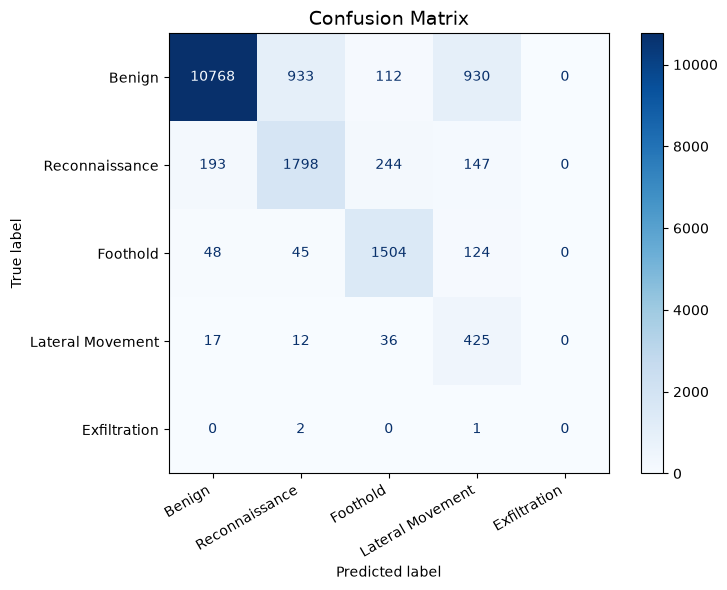

In [9]:
m = run_eval(model, test_loader)
print('\n===== TEST METRICS =====')
print(f'Accuracy        : {m["acc"]:.4f}')
print(f'F1  (weighted)  : {m["f1"]:.4f}')
print(f'F1  (macro)     : {f1_score(m["true"], m["pred"], average="macro", zero_division=0):.4f}')
print(f'Precision (w)   : {m["prec"]:.4f}')
print(f'Recall    (w)   : {m["rec"]:.4f}')
print()
print(classification_report(m['true'], m['pred'],
                             target_names=APT_PHASE_NAMES, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(
    confusion_matrix(m['true'], m['pred']),
    display_labels=APT_PHASE_NAMES
).plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Confusion Matrix', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('dapt2020_confusion_matrix.png', dpi=150)
plt.show()